Zadanie 10

Porównaj trzy warianty Gradient Descent na tym samym zbiorze danych.

Dataset: make_regression(n_samples=1000, n_features=1, noise=30)

Wymagania:
- Zaimplementuj wszystkie 3 warianty
- Zmierz czas wykonania
- Porównaj krzywe uczenia
- Określ, który wariant jest najefektywniejszy

Oczekiwany rezultat:
- Tabela porównawcza (czas, końcowy loss, liczba iteracji)
- Wykres krzywych uczenia


=== Tabela porównawcza ===
Metoda               | Waga       | Bias       | Czas (s)   | Końcowy Loss   | Aktualizacje
--------------------------------------------------------------------------------------------
Batch GD             | 16.4041    | 0.1358     | 0.0082     | 882.16         | 100
Mini-Batch GD (32)   | 11.8827    | 0.5233     | 0.1230     | 901.84         | 3200
Stochastic GD        | 16.5688    | 0.1846     | 0.4930     | 882.19         | 100000

=== Analiza efektywności ===
1. Najniższy Loss: Batch GD (882.16)
2. Najkrótszy Czas: Batch GD (0.0082s)


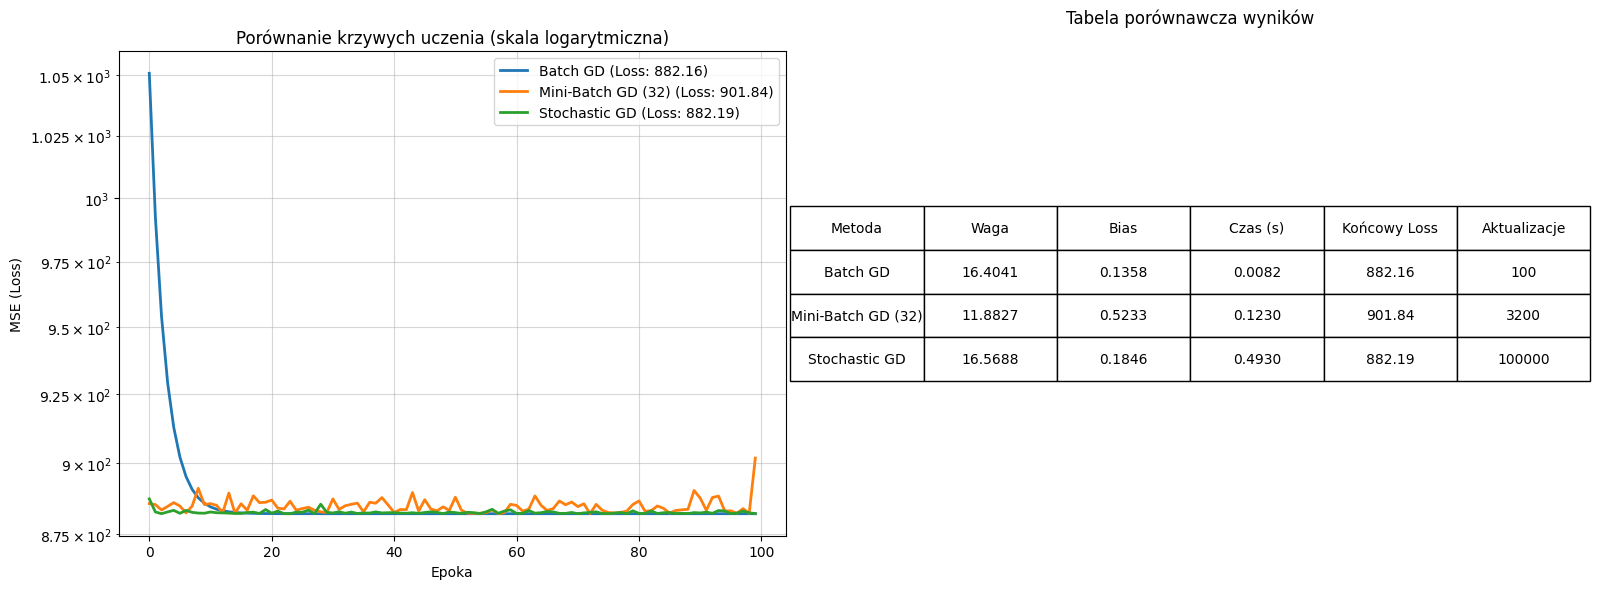

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
import time

# Przygotowanie danych
np.random.seed(42)
X_raw, y = make_regression(n_samples=1000, n_features=1, noise=30)
X = X_raw.flatten()

# Funkcje pomocnicze
def predict(X, w, b):
    return w * X + b

# Funkcja kosztu (Mean Squared Error)
def compute_mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def compute_gradients_batch(X, y, w, b):
    """Obliczenie gradientów dla regresji liniowej."""
    n = len(y)
    y_pred = predict(X, w, b)
    error = y - y_pred
    dw = (-2/n) * np.sum(error * X)
    db = (-2/n) * np.sum(error)

    return dw, db


# Implementacja wariantów

def batch_gradient_descent(X, y, lr=0.1, epochs=100):
    """Batch Gradient Descent - używa wszystkich danych w każdej iteracji"""
    w, b = 0.0, 0.0
    losses = []
    updates = 0
    
    for _ in range(epochs):
        # Wykorzystanie zachowanej funkcji compute_gradients_batch
        dw, db = compute_gradients_batch(X, y, w, b)
        w -= lr * dw
        b -= lr * db
        updates += 1
        losses.append(compute_mse(y, predict(X, w, b)))
        
    return w, b, losses, updates

def mini_batch_gradient_descent(X, y, lr=0.01, epochs=100, batch_size=32):
    """Mini-batch GD - używa małych porcji danych"""
    w, b = 0.0, 0.0
    n = len(y)
    losses = []
    updates = 0
    
    for _ in range(epochs):
        # Losowa kolejność danych
        indices = np.random.permutation(n)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        # Podziel na mini-batche
        for i in range(0, n, batch_size):
            X_i = X_shuffled[i:i+batch_size]
            y_i = y_shuffled[i:i+batch_size]
            
            y_pred = predict(X_i, w, b)
            
            dw = (-2/len(X_i)) * np.sum((y_i - y_pred) * X_i)
            db = (-2/len(X_i)) * np.sum(y_i - y_pred)
            
            w -= lr * dw
            b -= lr * db
            updates += 1
            
        losses.append(compute_mse(y, predict(X, w, b)))
        
    return w, b, losses, updates

def stochastic_gradient_descent(X, y, lr=0.001, epochs=100):
    """Stochastic GD - używa jednej obserwacji na raz"""
    w, b = 0.0, 0.0
    n = len(y)
    losses = []
    updates = 0
    
    for _ in range(epochs):
        # Losowa kolejność danych
        indices = np.random.permutation(n)

        for i in indices:
            y_pred = predict(X[i], w, b)
            
            dw = -2 * (y[i] - y_pred) * X[i]
            db = -2 * (y[i] - y_pred)
            
            w -= lr * dw
            b -= lr * db
            updates += 1
            
        losses.append(compute_mse(y, predict(X, w, b)))
        
    return w, b, losses, updates

# Uruchomienie wszystkich wariantów

epochs = 100
results = []

methods = [
    ("Batch GD", batch_gradient_descent, {'lr': 0.1, 'epochs': epochs}),
    ("Mini-Batch GD (32)", mini_batch_gradient_descent, {'lr': 0.05, 'epochs': epochs, 'batch_size': 32}),
    ("Stochastic GD", stochastic_gradient_descent, {'lr': 0.001, 'epochs': epochs}),
]

for name, func, params in methods:
    start_time = time.time()
    w, b, losses, updates = func(X, y, **params)
    end_time = time.time()
    
    results.append({
        "name": name,
        "w": w,
        "b": b,
        "time": end_time - start_time,
        "final_loss": losses[-1],
        "updates": updates,
        "losses": losses
    })

# Wyświetlenie tabeli
print("\n=== Tabela porównawcza ===")
print(f"{'Metoda':<20} | {'Waga':<10} | {'Bias':<10} | {'Czas (s)':<10} | {'Końcowy Loss':<14} | {'Aktualizacje'}")
print("-" * 92)
for res in results:
    print(f"{res['name']:<20} | {res['w']:<10.4f} | {res['b']:<10.4f} | {res['time']:<10.4f} | {res['final_loss']:<14.2f} | {res['updates']}")
print()

# Analiza efektywności

# Kryterium 1: Najniższy loss
best_by_loss = min(results, key=lambda x: x["final_loss"])

# Kryterium 2: Najkrótszy czas
best_by_time = min(results, key=lambda x: x["time"])

print("=== Analiza efektywności ===")
print(f"1. Najniższy Loss: {best_by_loss['name']} ({best_by_loss['final_loss']:.2f})")
print(f"2. Najkrótszy Czas: {best_by_time['name']} ({best_by_time['time']:.4f}s)")

# Wizualizacja

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for res in results:
    ax1.plot(res["losses"], label=f"{res['name']} (Loss: {res['final_loss']:.2f})", linewidth=2)

ax1.set_xlabel('Epoka')
ax1.set_ylabel('MSE (Loss)')
ax1.set_title('Porównanie krzywych uczenia (skala logarytmiczna)')
ax1.set_yscale('log')
ax1.legend()
ax1.grid(True, which="both", ls="-", alpha=0.5)

ax2.axis('off') 
columns = ['Metoda', 'Waga', 'Bias', 'Czas (s)', 'Końcowy Loss', 'Aktualizacje']
cell_text = []
for res in results:
    cell_text.append([
        res['name'],
        f"{res['w']:.4f}",
        f"{res['b']:.4f}",
        f"{res['time']:.4f}",
        f"{res['final_loss']:.2f}",
        str(res['updates'])
    ])

table = ax2.table(
    cellText=cell_text,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2.5)  
ax2.set_title('Tabela porównawcza wyników', pad=20)

plt.tight_layout()
plt.show()